In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import torch
import nibabel as nb

from tqdm.auto import tqdm
from os.path import join as pjoin

DATA7_PATH = "/System/Volumes/Data/data/data7"
projects_path = f"{DATA7_PATH}/network_control/projects"
sys.path.insert(1, projects_path)

import voxel_analysis as va
import torch_math_tools as tmt
import CAP_tools

NC_path = f"{DATA7_PATH}/network_control/projects/network_control"
sys.path.insert(1, NC_path)
import surface_mapping as sfm
import load
import plot

# Load Data:
### Load Subjects [] remove this stuff

In [2]:
_, _, _, subject_list = load.load_constants(400)

In [3]:
param_dir = "/data/data7/network_control/scripts/_params"
HCP_CAP_param_prefix = pjoin(param_dir, "HCP_7T_CAP_analysis/HCP_7T_CAP_analysis")

get_HCP_cifti_list = lambda session, cifti_type: f"{HCP_CAP_param_prefix}_{session}_{cifti_type}_list.txt"

def get_cifti_paths(cifti_list_path):
    with open(cifti_list_path, "r") as file:
        return file.read().strip().split()

def filter_sort_cifti_paths(paths, subjects):
    filtered_paths = [p for p in paths if any(subj in p for subj in subjects)]
    assert len(filtered_paths) == len(subjects)
    key = lambda path: next(i for i, subj in enumerate(subjects) if subj in path)
    return sorted(filtered_paths, key=key)

def get_HCP_cifti_paths(session, cifti_type, subject_list):
    cifti_list_path = get_HCP_cifti_list(session, cifti_type)
    cifti_paths = get_cifti_paths(cifti_list_path)
    cifti_paths = filter_sort_cifti_paths(cifti_paths, subject_list)
    return cifti_paths

### Load Ciftis

In [4]:
session = "tfMRI_MOVIE_7T_DAY_1"
# session = "rfMRI_REST1_7T_PA"

dtseries_paths = get_HCP_cifti_paths(session, "dtseries", subject_list)
ptseries_paths = get_HCP_cifti_paths(session, "400_ptseries", subject_list)

In [5]:
subject_index = 0

dtseries = nb.load(dtseries_paths[subject_index])
ptseries = nb.load(ptseries_paths[subject_index])
voxel_data = dtseries.get_fdata()
parcel_data = ptseries.get_fdata()

In [6]:
dtseries_paths[subject_index]

'/System/Volumes/Data/data/data7/HCP_7T/100610/MNINonLinear/Results/tfMRI_MOVIE_7T_DAY_1/tfMRI_MOVIE_7T_DAY_1_Atlas_hp2000_clean_nilearn_ISCH.dtseries.nii'

### Cifti Map to Full Arrays

In [7]:
def hemisphere_to_full(values):
    """ """
    return np.concat([values["left"], values["right"]], axis=-1)

def full_to_hemi(values):
    n_half = values.shape[-1] // 2
    return {"left": values.T[:n_half].T, "right": values.T[n_half:].T}

# Core Functional Connectivity Analysis

In [8]:
def get_cortex_data(full_data, cifti):
    pax = cifti.header.get_axis(1)
    slice_LUT = {structure: sl for structure, sl,_  in pax.iter_structures()}
    cortex_data_L = full_data[:, slice_LUT["CIFTI_STRUCTURE_CORTEX_LEFT"]]
    cortex_data_R = full_data[:, slice_LUT["CIFTI_STRUCTURE_CORTEX_RIGHT"]]
    return np.hstack([cortex_data_L, cortex_data_R])

In [9]:
priors_path = os.path.join(projects_path, "voxel_analysis/resources/priors.mat")

priors = scipy.io.loadmat(priors_path)
FC, spatial, network_labels, _ = priors["Priors"][0, 0]
network_labels = np.array([lab[0][0] for lab in network_labels])
FC, spatial = FC.T, spatial.T

In [10]:
example_cifti = nb.load(va.constants.EXAMPLE_DTSERIES)

In [ ]:
i = 8
spatial_values_i = CAP_tools.utils.cifti_map(None, spatial[i], example_cifti)
FC_values_i = CAP_tools.utils.cifti_map(None, FC[i], example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(spatial_values_i, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"{network_labels[i]} Spatial Probability")

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(FC_values_i, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"{network_labels[i]} Functional Connectivity")

In [11]:
full_data = example_cifti.get_fdata()
vertex_data = get_cortex_data(full_data, example_cifti)

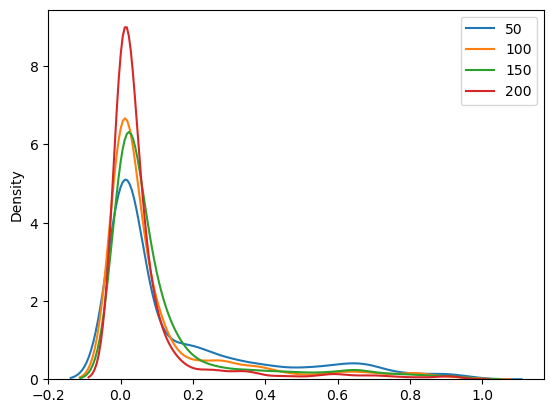

In [12]:
k_partition = 50

remove_diag = lambda array: array[~np.eye(array.shape[0], dtype=bool)]
for k_step in range(1, 5):
    hf_ind = np.argpartition(spatial[0], -k_partition * k_step)[-k_partition * k_step:][:k_partition]
    hf_roi_vertices = vertex_data[:, hf_ind]
    sns.kdeplot(remove_diag(np.corrcoef(hf_roi_vertices.T)).ravel() ** 2, bw_method=0.2, label=k_step * k_partition)
plt.legend()

In [11]:
def np_corr(x, y):
    """ """
    x, y = x.T, y.T
    x_demeaned = x - x.mean(axis=1, keepdims=True)
    y_demeaned = y - y.mean(axis=1, keepdims=True)

    x_norm = x_demeaned / np.sqrt(np.sum(x_demeaned ** 2, axis=1, keepdims=True))
    y_norm = y_demeaned / np.sqrt(np.sum(y_demeaned ** 2, axis=1, keepdims=True))
    return x_norm @ y_norm.T


def torch_corr(x, y):
    """ """
    x, y = x.T, y.T
    x_demeaned = x - x.mean(axis=1, keepdims=True)
    y_demeaned = y - y.mean(axis=1, keepdims=True)

    x_norm = x_demeaned / torch.sqrt(torch.sum(x_demeaned ** 2, axis=1, keepdims=True))
    y_norm = y_demeaned / torch.sqrt(torch.sum(y_demeaned ** 2, axis=1, keepdims=True))
    return x_norm @ y_norm.T

In [12]:
si = spatial[i] >= 0.80
print("Non Zero Mask Count: ", np.count_nonzero(si))

NameError: name 'i' is not defined

In [ ]:
hf_roi_vertices = vertex_data[:, si]
vertex_data[:, ~si].shape

In [13]:
devp = dict(device="mps")

a = hf_roi_vertices
b = vertex_data[:, :]
# a = np.mean(a, axis=1).reshape(-1, 1)

cor = torch_corr(a, vertex_data, **devp)
cor[cor < 0.2] = 0
# cor[:, si] = 0
# cor = np.mean(cor, axis=0).reshape(1, -1)
w = spatial[i][si] ** 2
w /= np.sum(spatial[i][si])
cor = np.sum(w.reshape(-1, 1) * cor, axis=0, keepdims=True)

NameError: name 'hf_roi_vertices' is not defined

In [14]:
sfc_values_i = CAP_tools.utils.cifti_map(None, cor[0], example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(sfc_values_i, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"{network_labels[i]} Spatial Restricted FC")

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(spatial_values_i, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"{network_labels[i]} Spatial Values")

NameError: name 'cor' is not defined

In [15]:
rs_dtseries_list_path = "/data/data7/network_control/scripts/_params/EC_CAP_analysis/EC_CAP_analysis_RS_fMRI_maps_dtseries_list.txt"

with open(rs_dtseries_list_path, "r") as f:
    dtseries_paths = f.read().strip().split()

subject_list = [path.split("/MNI")[0].split("/")[-1] for path in dtseries_paths]

In [16]:
def get_raw_core_FC(cifti_path, si):
    """ """
    cifti = nb.load(cifti_path)
    full_data = cifti.get_fdata()
    vertex_data = get_cortex_data(full_data, cifti)

    devp = dict(device="mps")
    cor = torch_corr(vertex_data[:, si], vertex_data, **devp)
    return cor

In [17]:
w = spatial[i][si] ** 2
w /= np.sum(spatial[i][si])
cor = np.sum(w.reshape(-1, 1) * cor, axis=0, keepdims=True)

NameError: name 'i' is not defined

In [18]:
raw_cor_set = []
for path in tqdm(dtseries_paths):
    # raw_cor_set.append(get_raw_core_FC(path, si))
    pass

  0%|          | 0/54 [00:00<?, ?it/s]

In [19]:
raw_cor_set = np.array(raw_cor_set)

In [20]:
cor_set = raw_cor_set.copy()
cor_set[cor_set < 0] = 0

In [21]:
w = spatial[i][si].reshape(-1, 1) #** 2
w /= np.sum(spatial[i][si])

NameError: name 'i' is not defined

In [22]:
cor_m_set = np.array([np.sum(w * cor_i, axis=0, keepdims=False) for cor_i in cor_set])

In [23]:
szp_label = np.array(["_08_" in s for s in subject_list])

szp_m = np.mean(cor_m_set[szp_label], axis=0)
hc_m = np.mean(cor_m_set[~szp_label], axis=0)
fc_content = np.nanmean(cor_m_set, axis=1)

IndexError: boolean index did not match indexed array along dimension 0; dimension is 0 but corresponding boolean dimension is 54

In [31]:
t, p = scipy.stats.ttest_ind(fc_content[szp_label], fc_content[~szp_label])
print(p)

NameError: name 'fc_content' is not defined

In [32]:
sns.boxplot(y=fc_content, x=szp_label)

NameError: name 'fc_content' is not defined

In [197]:
t_s, p_s = scipy.stats.ttest_ind(cor_m_set[szp_label], cor_m_set[~szp_label])

In [180]:
p_s[np.isnan(p_s)] = 1

In [181]:
q_s = scipy.stats.false_discovery_control(p_s)

Text(0.5, 1.0, 'HC Default_Parietal Spatial Restricted FC')

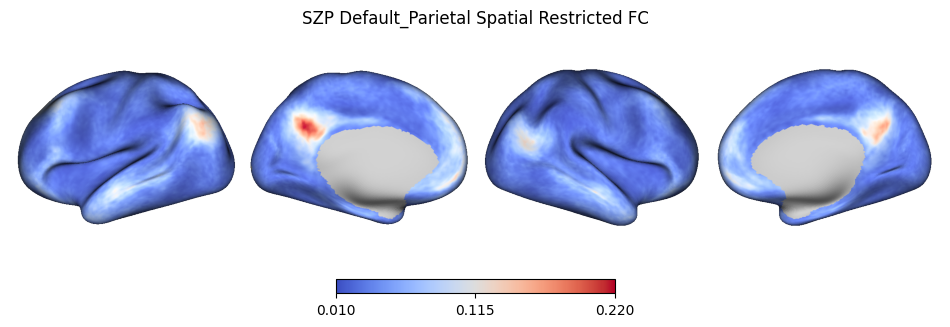

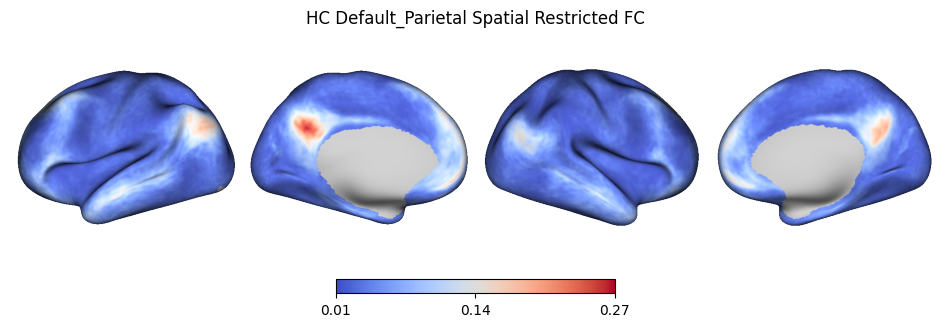

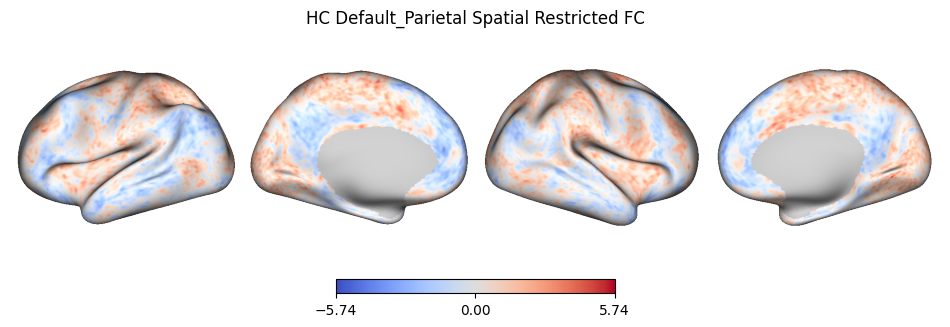

In [182]:
szp_m_values = CAP_tools.utils.cifti_map(None, szp_m, example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(szp_m_values, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"SZP {network_labels[i]} Spatial Restricted FC")

hc_m_values = CAP_tools.utils.cifti_map(None, hc_m, example_cifti)
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(hc_m_values, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"HC {network_labels[i]} Spatial Restricted FC")

t_values = CAP_tools.utils.cifti_map(None, t_s, example_cifti)
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(t_values, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"HC {network_labels[i]} Spatial Restricted FC")

# Load infomaps dlabels and assign to network

In [16]:
import glob
pm_dir = "/data/data7/network_control/results/EC_analysis/precision_maps/RS_fMRI_maps"
partition_paths = glob.glob(pm_dir + "/*/*parcellation*")
# dlabel_paths = glob.glob(pm_dir + "/*/*.dlabel.nii")
# dlabel = nb.load(dlabel_paths[0])

In [17]:
# t_values = CAP_tools.utils.cifti_map(None, dlabel.get_fdata()[0], dlabel)
# fig, ax = plt.subplots(figsize=(12, 4))
# ax, _ = sfm.surface_plot(t_values, cmap=plt.cm.coolwarm, ax=ax)
# ax.set_title(f"HC {network_labels[i]} Spatial Restricted FC")

In [18]:
# roi_ind = vertex_labels == 360

# t_values = CAP_tools.utils.cifti_map(None, roi_ind, dlabel)
# fig, ax = plt.subplots(figsize=(12, 4))
# ax, _ = sfm.surface_plot(t_values, cmap=plt.cm.coolwarm, ax=ax)
# ax.set_title(f"HC {network_labels[i]} Spatial Restricted FC")

In [19]:
def get_partition_cortex(partition, cifti):
    """ """
    _, partition = va.pm.assign_networks.process_partition(partition, cifti)
    vertex_labels = np.full(np.max(partition[0]) + 1, fill_value=np.nan)
    vertex_labels[partition[0]] = partition[1]
    return get_cortex_data(vertex_labels.reshape(1, -1), cifti)[0]

# Nan Shard Debugging

In [21]:

# sc_path = "../tests/outputs/example_voxel_FC_S1_D10.npz"
sc_path = "../tests/outputs/example_voxel_FC_S10_D30.npz"
sc_path = "../tests/outputs/hole_test_S1.npz"
# sc_path = "../tests/outputs/hole_test_S10.npz"
sc_path = "../tests/outputs/example_voxel_FC_S1_D10_SC.npz"


# [] test to see if the s10 npz has the same problems, if not then issues maybe be due to heavy filtering
# [] if s10 npz also has same problems, may be due to other algorithm part
# [] symmetric mode gives very different results :(
# [] test results with SC exclusion
# [] test results with masking
sc = scipy.sparse.load_npz(sc_path)
sc

<91282x91282 sparse matrix of type '<class 'numpy.float32'>'
	with 7181148 stored elements in Compressed Sparse Row format>

In [22]:
sc.sum(axis=0)

matrix([[36.038677 , 15.0035095, 34.382053 , ...,  9.208517 ,  6.7913465,
          8.698821 ]], dtype=float32)

In [23]:
z = np.array((sc > 0).sum(axis=0)).ravel()
b = np.array((sc > 0).sum(axis=1)).ravel()

In [24]:
np.mean((z + b) > 0)

0.9997370785039766

In [25]:
np.sum(z > 0), np.sum(b > 0)

(91258, 91258)

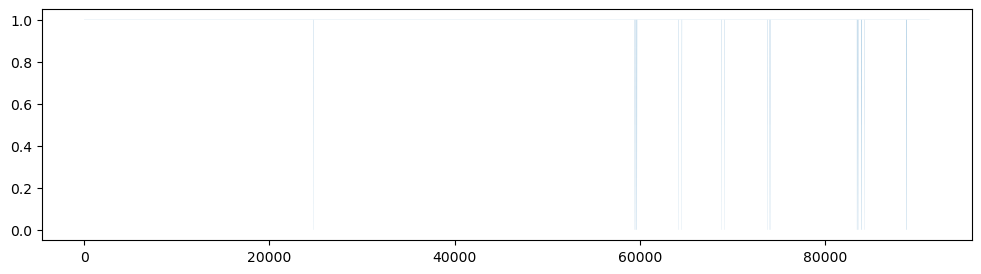

In [26]:
fig, ax = plt.subplots(figsize=(12, 3))
plt.plot(z > 0, alpha=1, linewidth=0.05)

In [209]:
# part_path = "../tests/outputs/example_parcellation_S1_D10_SC.npy" # has holes
# part_path = "../tests/outputs/example_parcellation_S1_D10.npy" # has holes
# part_path = "../tests/outputs/example_parcellation_S1_D30.npy" # has holes
part_path = "../tests/outputs/example_parcellation_S10_D30.npy" # no holes
part_path = "../tests/outputs/hole_check_FC_S10_D30.npy" # no holes, so unlikely infomap problem?
part_path = "../tests/outputs/hole_check_FC_S1_D30.npy" # has holes, so unlikely infomap problem?
part_path = "../tests/outputs/hole_check_FC_S1_D10_SC.npy" # has holes, so unlikely infomap problem?
part_path = "../tests/outputs/hole_test_S1.npy" # has holes, so unlikely infomap problem?
# part_path = "../tests/outputs/hole_test_S10.npy" #

part_path = "../tests/outputs/example_parcellation_S1_D10_SC.npy" # has holes


In [210]:
partition = np.load(part_path)
vertex_labels = get_partition_cortex(partition, example_cifti)

(<Axes: >, <surfplot.plotting.Plot at 0x36caa91d0>)

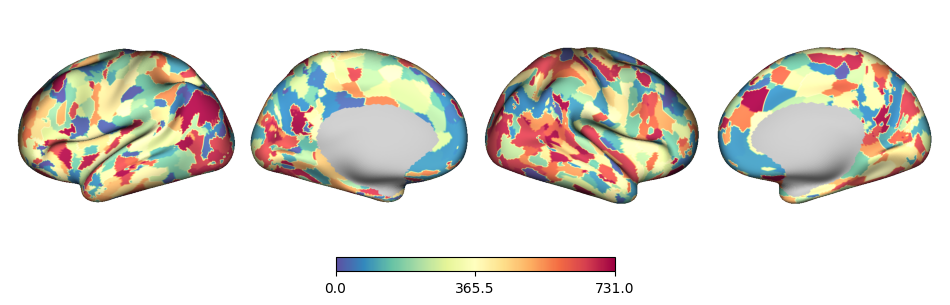

In [211]:
pm_values, _ = va.pm.process_partition(partition, example_cifti, filter_subcortex=False)
sfm.surface_plot(pm_values, cmap=plt.cm.Spectral_r)

In [419]:
index, groups = partition

Text(0.5, 1.0, 'HC Default_Retrosplenial Spatial Restricted FC')

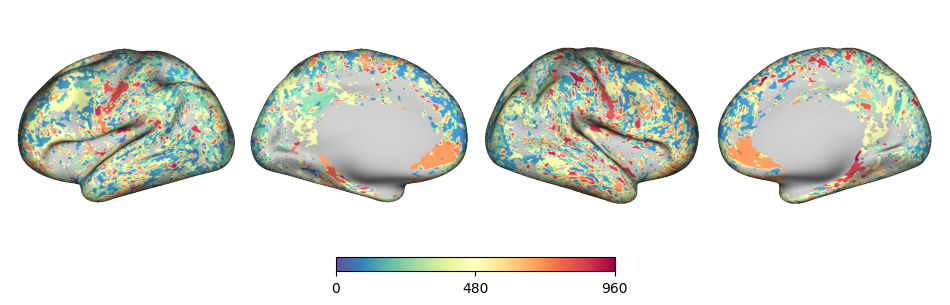

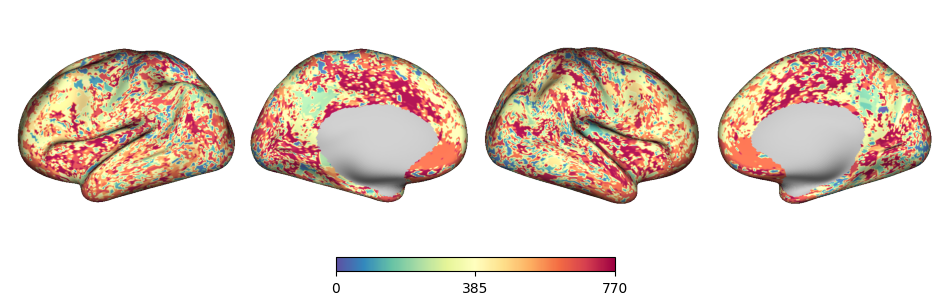

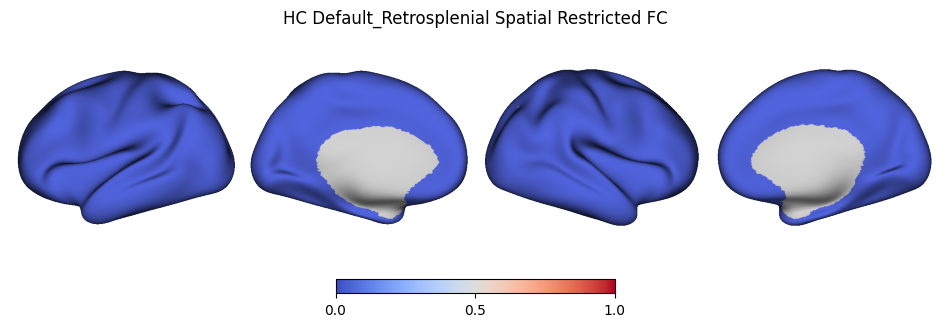

In [420]:
sfm.surface_plot(pm_values, cmap=plt.cm.Spectral_r)
vl_values = CAP_tools.utils.cifti_map(None, vertex_labels, example_cifti)
sfm.surface_plot(vl_values, cmap=plt.cm.Spectral_r)

roi_ind = vertex_labels == 0

t_values = CAP_tools.utils.cifti_map(None, roi_ind, example_cifti)
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(t_values, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"HC {network_labels[i]} Spatial Restricted FC")

# Spatial and Functional Assigments

In [20]:
example_cifti = nb.load(va.constants.EXAMPLE_DTSERIES)
full_data = example_cifti.get_fdata()
vertex_data = get_cortex_data(full_data, example_cifti)

In [21]:
def cortex_plot(data, cifti, rois=None, cmap=plt.cm.coolwarm):
    """ """
    data_values = CAP_tools.utils.cifti_map(rois, data, cifti)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax, _ = sfm.surface_plot(data_values, cmap=cmap, ax=ax)
    return ax, data_values

In [22]:
pm_dir = "/data/data7/network_control/results/EC_analysis/precision_maps/RS_fMRI_maps"
partition_paths = glob.glob(pm_dir + "/*/*parcellation*")

In [23]:
partition = np.load(partition_paths[0])
vertex_labels = va.na.get_partition_cortex(partition, example_cifti)
# vn, vns = va.na.get_network_assignment_labels(vertex_labels, vertex_data, network_labels, spatial, FC)

vn, vns = np.load("../tests/outputs/example_S1_SC_networks.npy")

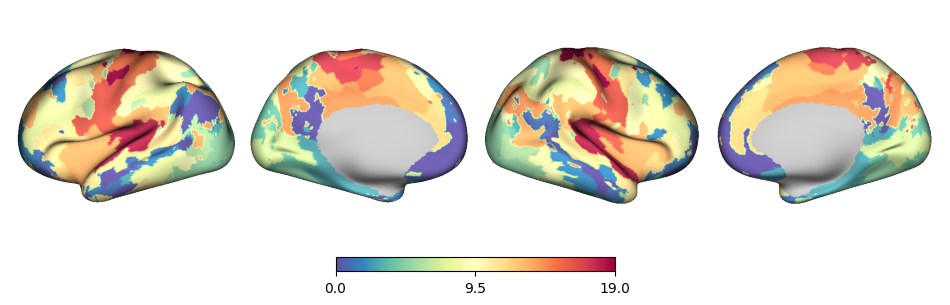

In [817]:
cortex_plot(vn, example_cifti, cmap=plt.cm.Spectral_r);

In [28]:
tr_s = []
for dtseries_path in tqdm(dtseries_paths):
    cifti = nb.load(dtseries_path)
    tr_s.append(cifti.shape[0])
tr_s = np.array(tr_s)

  0%|          | 0/54 [00:00<?, ?it/s]

pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-

## REsults:



### S1_D30:
    PANSS_Tot_3F - Default_Anterolateral:: R = -0.43 0.05
    PSIComposite_ScaledScore - SomatoCognitiveAction:: R = -0.44 0.03
    ProcessingSpeedIndex - SomatoCognitiveAction:: R = -0.45 0.03

### S1_D0_SubCortex
positive language

In [25]:
pm_dir = "/data/data7/network_control/results/EC_analysis/precision_maps/RS_fMRI_maps"
# pm_dir = "/data/data7/network_control/results/EC_analysis/precision_maps/Task_fMRI_GBU_1"


sparsity = 0.1
# mask_filter = "_D10"
mask_filter = ""
subcortex = True

subcortex_tag = "_SC" if subcortex else ""
file_tag = f"S{sparsity * 10:.0f}{mask_filter}{subcortex_tag}"
partition_paths = glob.glob(pm_dir + f"/*/*parcellation*{file_tag}.npy")
rs_dtseries_list_path = "/data/data7/network_control/scripts/_params/EC_CAP_analysis/EC_CAP_analysis_RS_fMRI_maps_dtseries_list.txt"
print(file_tag)
with open(rs_dtseries_list_path, "r") as f:
    dtseries_paths = f.read().strip().split()

subject_list = [path.split("/MNI")[0].split("/")[-1] for path in dtseries_paths]
len(partition_paths)

S1_SC


54

In [29]:
network_paths = glob.glob(pm_dir + f"/*/*{file_tag}*networks*.npy")

In [30]:
np.array(subject_list)[tr_s < 1_000]

array(['ec_08_0034'], dtype='<U17')

In [31]:
for tr, subj in zip(tr_s, subject_list):
    pass
    # print(subj, f"{tr * .8 / 60:.1f}")

In [32]:
# network_path

In [33]:
na_s, ns_s = [], []
valid_subjects = []
for i, partition_path in enumerate(tqdm(partition_paths)):
    partition = np.load(partition_path)    
    # if len(np.unique(partition[1])) > 4000:
    if len(np.unique(partition[1])) > 10_000:
        print("skipped ", i, subject_list[i])
        continue

    vertex_labels = va.na.get_partition_cortex(partition, example_cifti)
    # vertex_networks, vertex_networks_str = get_spatial_assignments(vertex_labels, spatial, network_labels)
    vn, vns = va.na.get_network_assignment_labels(vertex_labels, vertex_data, network_labels, spatial, FC)

# for i, network_path in enumerate(tqdm(network_paths)):    
#     vn, vns = np.load(network_path)
    na_s.append(vn)
    ns_s.append(vns)
    valid_subjects.append(subject_list[i])

na_s, ns_s = np.array(na_s), np.array(ns_s)
valid_subjects = np.array(valid_subjects)
szp_index = np.array(["_08_" in v for v in valid_subjects])

  0%|          | 0/54 [00:00<?, ?it/s]

skipped  1 ec_00_0005
skipped  24 ec_00_0078
skipped  25 ec_08_0005
skipped  26 ec_08_0006
skipped  30 ec_08_0015
skipped  39 ec_08_0031


In [34]:
na_s, ns_s = np.array(na_s), np.array(ns_s)
valid_subjects = np.array(valid_subjects)

szp_index = np.array(["_08_" in v for v in valid_subjects])

### Get Surface Areas 

In [35]:
def get_vertex_surface_area(surface_file):
    # Load the GIFTI surface file
    gii = nb.load(surface_file)
    
    # Get the vertices and faces
    vertices = gii.darrays[0].data
    faces = gii.darrays[1].data

    # Compute surface area for each triangle
    tri_vertices = vertices[faces]
    a = tri_vertices[:, 1] - tri_vertices[:, 0]
    b = tri_vertices[:, 2] - tri_vertices[:, 0]
    cross_product = np.cross(a, b)
    triangle_areas = 0.5 * np.linalg.norm(cross_product, axis=1)

    # Distribute triangle areas to vertices
    vertex_areas = np.zeros(vertices.shape[0])
    for i in range(3):
        np.add.at(vertex_areas, faces[:, i], triangle_areas / 3)

    return vertex_areas

# Example usage:
# surface_file = "path/to/left_surface.surf.gii"
# vertex_areas = get_vertex_surface_area(surface_file)


In [36]:
generic_surf_file = "/data/data4/earlycort_7114/{subject}/MNINonLinear/fsaverage_LR32k/{subject}.{side}.midthickness.32k_fs_LR.surf.gii"

In [37]:
L_surf_files = [generic_surf_file.format(subject=subj.split("_16")[0], side="L") for subj in valid_subjects]
R_surf_files = [generic_surf_file.format(subject=subj.split("_16")[0], side="R") for subj in valid_subjects]

L_SA_all = np.expand_dims(np.array([get_vertex_surface_area(sf) for sf in L_surf_files]), -1)
R_SA_all = np.expand_dims(np.array([get_vertex_surface_area(sf) for sf in R_surf_files]), -1)

label_all_values = CAP_tools.utils.cifti_map(None, na_s, cifti)
compare_table = np.tile(np.arange(len(network_labels)), (len(valid_subjects), 1, 1))

R_sizes_all = R_SA_all * (label_all_values["right"].reshape(len(valid_subjects), -1, 1) == compare_table)
L_sizes_all = L_SA_all * (label_all_values["left"].reshape(len(valid_subjects), -1, 1) == compare_table)
sizes_all = R_sizes_all + L_sizes_all
size_frac_all = sizes_all / sizes_all.sum(axis=(1, 2), keepdims=True)

## MAke DF

In [690]:
# z = np.array([(ns_s == net).mean(axis=1) for net in network_labels]).T
z = size_frac_all.sum(axis=1)

df = pd.DataFrame(z, columns=network_labels)
df["subject"] = valid_subjects
df["szp"] = np.array(["HC", "Szp"])[df["subject"].str.contains("_08_") * 1]

vsi = ~np.isin(valid_subjects, ["ec_08_0034"])
df = df.loc[vsi]

In [691]:
mdf = pd.melt(df, id_vars=["subject", "szp"], var_name="network", value_name="n_vertices")

<Axes: xlabel='n_vertices', ylabel='network'>

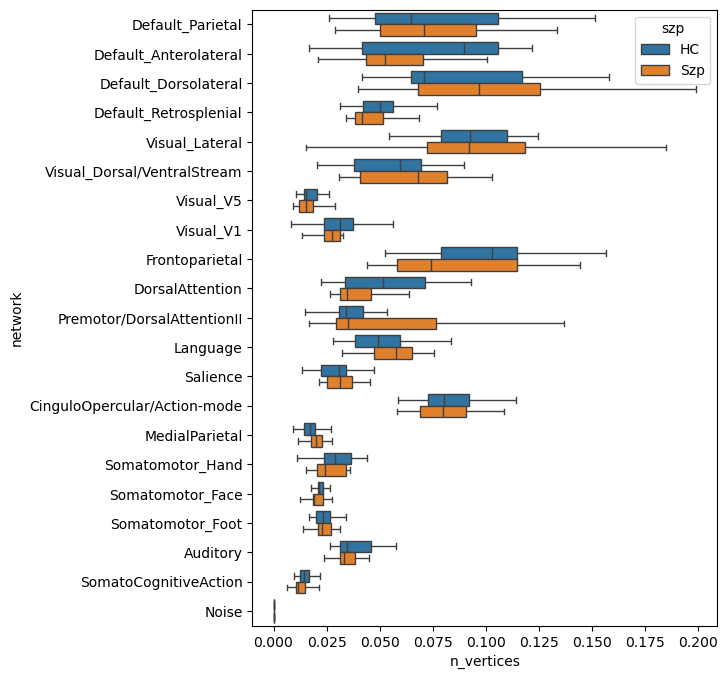

In [692]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.boxplot(data=mdf, y="network", x="n_vertices", hue="szp", showfliers=False, ax=ax)

In [693]:
szp_df = df.loc[df["szp"] == "Szp"]
hc_df = df.loc[df["szp"] != "Szp"]

In [740]:
t_s, p_s = scipy.stats.ttest_ind(szp_df[network_labels], hc_df[network_labels])

In [ ]:
szp_m_sizes = szp_df[network_labels].mean()
hc_m_sizes = hc_df[network_labels].mean()
size_ratio = szp_m_sizes / hc_m_sizes

sig_index = p_s < 0.05
print(network_labels[sig_index], p_s[sig_index])

for n, sr, p, in zip(network_labels, size_ratio, p_s):
    if np.isnan(p):
        continue
    print(f"size: {sr:.2f} :: p = {p:.3f} :: {n}" + "*" * ((p < 0.05) * 3))

In [697]:
size_ratio[sig_index], size_ratio

(Language          1.198568
 MedialParietal    1.300059
 dtype: float64,
 Default_Parietal                0.954554
 Default_Anterolateral           0.773254
 Default_Dorsolateral            1.116687
 Default_Retrosplenial           0.907451
 Visual_Lateral                  1.028058
 Visual_Dorsal/VentralStream     1.171864
 Visual_V5                       0.997269
 Visual_V1                       0.873745
 Frontoparietal                  0.853837
 DorsalAttention                 0.858304
 Premotor/DorsalAttentionII      1.309572
 Language                        1.198568
 Salience                        1.215297
 CinguloOpercular/Action-mode    0.959715
 MedialParietal                  1.300059
 Somatomotor_Hand                1.149310
 Somatomotor_Face                0.957901
 Somatomotor_Foot                0.923803
 Auditory                        0.993312
 SomatoCognitiveAction           0.875103
 Noise                                NaN
 dtype: float64)

### demographic correlations

In [698]:
demo_path = "/data/data7/network_control/resources/excel/GBU_tasit_demographics_all.tsv"

pdf = pd.read_csv(demo_path, sep="\t")
pdf["subject"] = pdf["PCode"]
pdf = pdf.merge(df, on="subject").reset_index(drop=True)

zpdf = pdf.query("szp == 'Szp'").reset_index(drop=True)

In [699]:
cols = ['AGE', 'Age at test', 'CPZTotal', 'ER40_Total', 'ER40_Total_Per',
       'Edinburgh score', 'Gender', 'PANSS_Neg_3F','PANSS_Pos_3F', 'PANSS_Tot_3F',
       'PSIComposite_ScaledScore', 'Participant SES', 'ProcessingSpeedIndex', 'Sarcasm_total',
       'TotalCorrect', 'TotalLiesCorrect', 'TotalSarcCorrect', 'WRAT_ScaledScore',
       'highest grade achieved',
       'Default_Parietal', 'Default_Anterolateral', 'Default_Dorsolateral',
       'Default_Retrosplenial', 'Visual_Lateral',
       'Visual_Dorsal/VentralStream', 'Visual_V5', 'Visual_V1',
       'Frontoparietal', 'DorsalAttention', 'Premotor/DorsalAttentionII',
       'Language', 'Salience', 'CinguloOpercular/Action-mode',
       'MedialParietal', 'Somatomotor_Hand', 'Somatomotor_Face',
       'Somatomotor_Foot', 'Auditory', 'SomatoCognitiveAction', 'Noise']

cols = network_labels[sig_index]

In [721]:
dem_vars = ["AGE", 'CPZTotal', 'ER40_Total', 'ER40_Total_Per',
           'Gender', 'PANSS_Neg_3F','PANSS_Pos_3F', 'PANSS_Tot_3F',
           'PSIComposite_ScaledScore', 'Participant SES', 'ProcessingSpeedIndex', 'Sarcasm_total',
           'TotalCorrect', 'TotalLiesCorrect', 'TotalSarcCorrect', 'WRAT_ScaledScore']

size_vars = network_labels[sig_index]
# size_vars = network_labels[:-1]
alpha = 0.05
print("Szp")
sig_clin_vars = []
sig_size_vars = []
for var1 in dem_vars:
    for var2 in size_vars:
        
        cdf = zpdf[[var1, var2]].dropna()        
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < alpha:
            sig_clin_vars.append(var1)
            sig_size_vars.append(var2)
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.3f}")


print("\n\nHealthy Controls")
for var1 in dem_vars:
    for var2 in size_vars:
        cdf = pdf.query("szp == 'HC'")[[var1, var2]].dropna() 
        if len(cdf) < 2:
            continue
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < alpha:
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.3f}")


print("\n\nAll Subjects")
for var1 in dem_vars:
    for var2 in size_vars:
        cdf = pdf[[var1, var2]].dropna()        
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < alpha:
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.3f}")

Szp
PANSS_Pos_3F - Language            :: R = -0.56 0.010
Sarcasm_total - MedialParietal     :: R = -0.55 0.007
TotalCorrect - MedialParietal      :: R = -0.44 0.034
TotalLiesCorrect - MedialParietal  :: R = -0.56 0.006
WRAT_ScaledScore - Language        :: R = -0.49 0.027


Healthy Controls
Participant SES - MedialParietal   :: R = -0.45 0.040


All Subjects
PANSS_Pos_3F - Language            :: R = -0.56 0.010
PSIComposite_ScaledScore - Language:: R = -0.45 0.004
ProcessingSpeedIndex - Language    :: R = -0.44 0.006
Sarcasm_total - MedialParietal     :: R = -0.41 0.010
TotalCorrect - Language            :: R = -0.35 0.023
TotalCorrect - MedialParietal      :: R = -0.47 0.002
TotalLiesCorrect - MedialParietal  :: R = -0.48 0.001
TotalSarcCorrect - Language        :: R = -0.39 0.012
TotalSarcCorrect - MedialParietal  :: R = -0.34 0.025
WRAT_ScaledScore - Language        :: R = -0.52 0.001


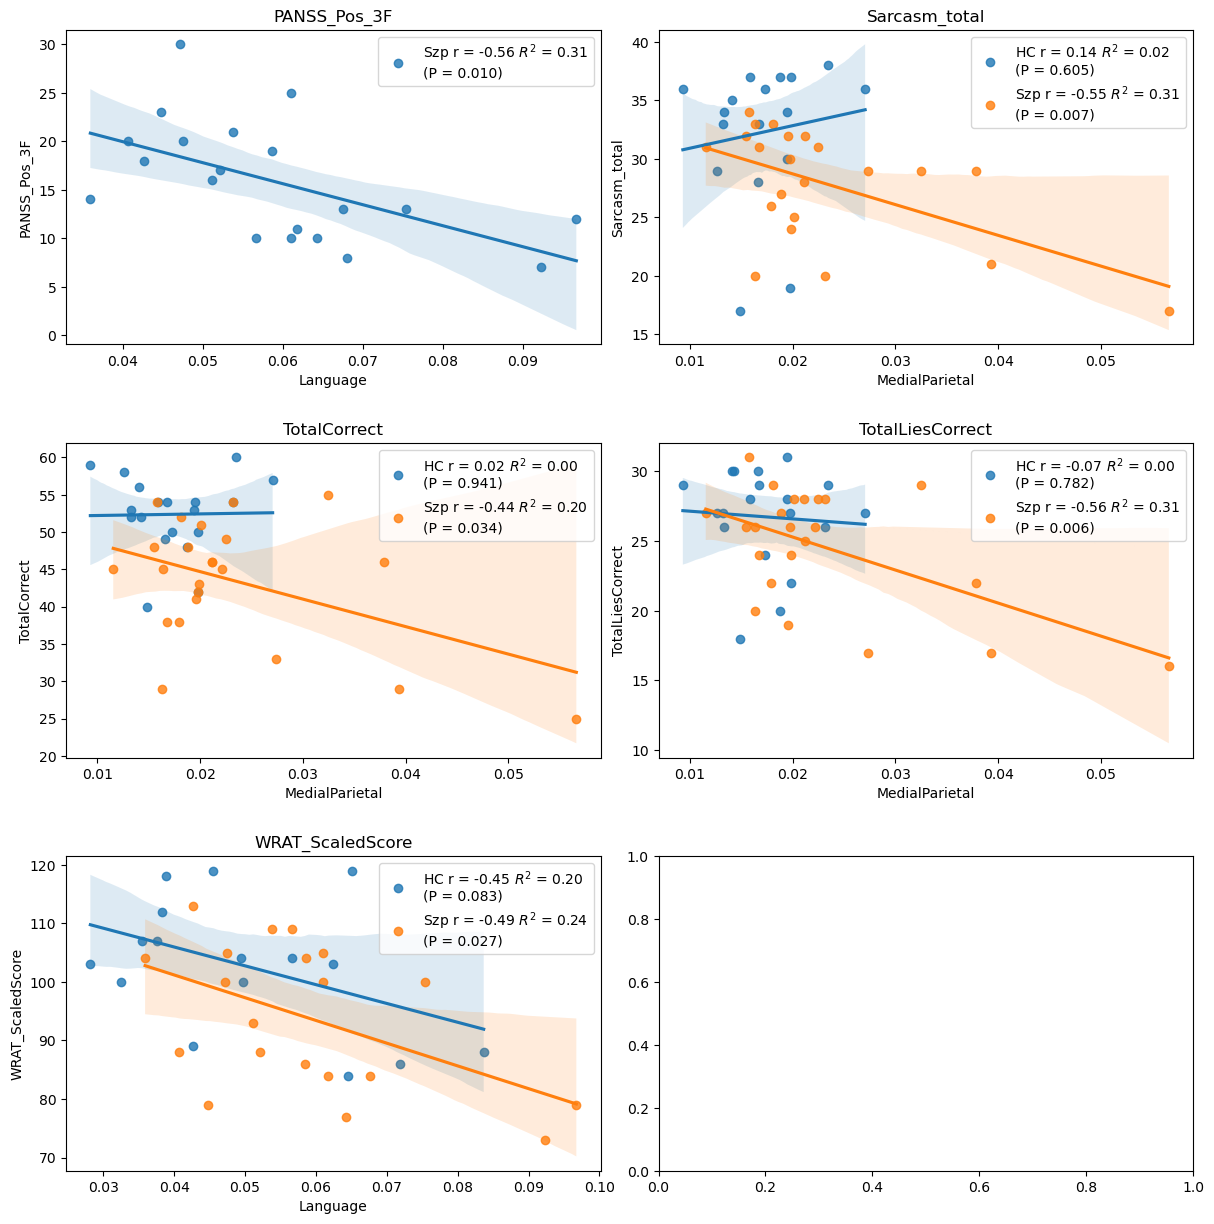

In [701]:
hc_pdf = pdf.query("szp == 'HC'")
ncols = 2
nrows = int(max(np.ceil(len(sig_clin_vars) / ncols), 1))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
fig.tight_layout(h_pad=5)
for ax, var1, var2 in zip(axes.ravel(), sig_clin_vars, sig_size_vars):
    if np.sum(~np.isnan(hc_pdf[var1])) > 3:
        plot.regplot(hc_pdf[var2], hc_pdf[var1], label="HC", ax=ax)
    plot.regplot(zpdf[var2], zpdf[var1], label="Szp", ax=ax)
    ax.set(title=f"{var1}")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


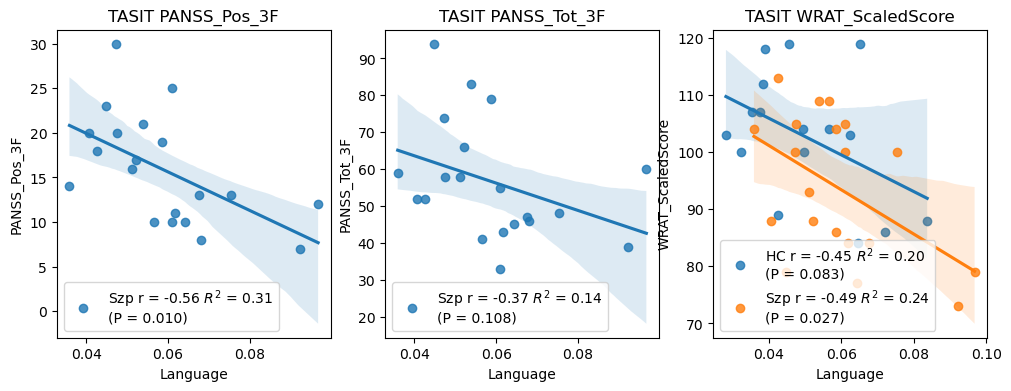

In [702]:
# clin_vars = ["TotalCorrect", "TotalLiesCorrect", "TotalSarcCorrect"]
clin_vars = ["PANSS_Pos_3F", "PANSS_Tot_3F", "WRAT_ScaledScore"]
hc_pdf = pdf.query("szp == 'HC'")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax = axes[0]
for ax, var in zip(axes, clin_vars):
    plot.regplot(hc_pdf["Language"], hc_pdf[var], label="HC", ax=ax)
    plot.regplot(zpdf["Language"], zpdf[var], label="Szp", ax=ax)
    ax.set(title=f"TASIT {var}")

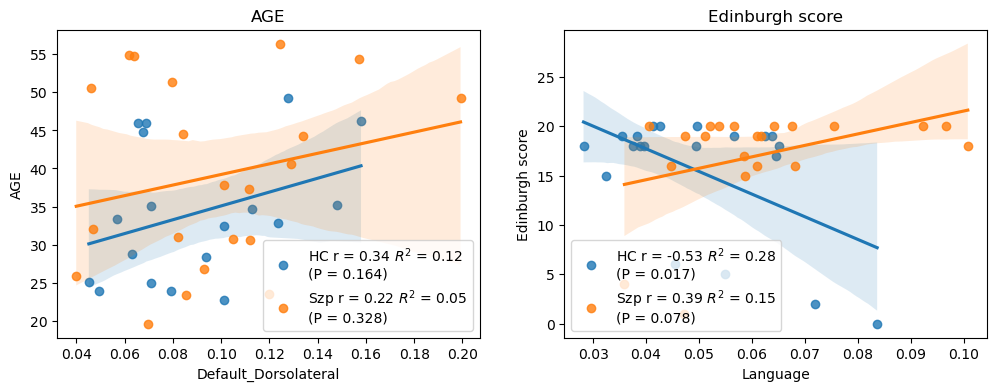

In [703]:
other_vars = ["AGE", "Edinburgh score"]
size_vars = ["Default_Dorsolateral", "Language"]
hc_pdf = pdf.query("szp == 'HC'")
fig, axes = plt.subplots(1, len(other_vars), figsize=(12, 4))
for ax, var, svar in zip(axes, other_vars, size_vars):
    plot.regplot(hc_pdf[svar], hc_pdf[var], label="HC", ax=ax)
    plot.regplot(zpdf[svar], zpdf[var], label="Szp", ax=ax)
    ax.set(title=var)

In [704]:
network_interest = "Language"
# network_interest = "MedialParietal"

In [705]:
nl.shape

(48, 59412)

In [706]:
nl = ns_s == network_interest
szp_net_prob = nl[szp_index].mean(axis=0) * 100

szp_net_prob_values = CAP_tools.utils.cifti_map(None, szp_net_prob, example_cifti)
hc_net_prob = nl[~szp_index].mean(axis=0) * 100
hc_net_prob_values = CAP_tools.utils.cifti_map(None, hc_net_prob, example_cifti)

prob_diff = szp_net_prob - hc_net_prob
prob_diff_values = CAP_tools.utils.cifti_map(None, prob_diff, example_cifti)

# prob_diff = np.log2(np.clip(szp_net_prob / hc_net_prob, 0.01, 10))
# prob_diff_values = CAP_tools.utils.cifti_map(None, prob_diff, example_cifti)
# odds_prob = np.log2(np.clip(szp_net_prob / hc_net_prob, 0.5, 2))
# odds_prob_values = CAP_tools.utils.cifti_map(None, odds_prob, example_cifti)

# fig, ax = plt.subplots(figsize=(12, 4))
# ax, _ = sfm.surface_plot(szp_net_prob_values, cmap=plt.cm.Spectral_r, ax=ax)
# ax.set_title(f"SzP {network_interest} Network Probability")

# fig, ax = plt.subplots(figsize=(12, 4))
# ax, _ = sfm.surface_plot(hc_net_prob_values, cmap=plt.cm.Spectral_r, ax=ax)
# ax.set_title(f"HC {network_interest} Network Probability")

# odds_prob = np.log2(np.clip(szp_net_prob / hc_net_prob, 0.5, 2))
# odds_prob_values = CAP_tools.utils.cifti_map(None, odds_prob, example_cifti)
# fig, ax = plt.subplots(figsize=(12, 4))
# ax, _ = sfm.surface_plot(odds_prob_values, cmap=plt.cm.coolwarm, ax=ax)
# ax.set_title(f"{network_interest} Network SzP - HC Log Odds Ratio")


# fig, ax = plt.subplots(figsize=(12, 4))
# ax, _ = sfm.surface_plot(prob_diff_values, cmap=plt.cm.coolwarm, ax=ax)
# ax.set_title(f"{network_interest} Network SzP - HC Probability Difference")

sfm.write_values_to_dscalar(
    prob_diff_values,
    "/data/data7/network_control/projects/voxel_analysis/tests/outputs/ex.dscalar.nii",
    scalar_name="SzP - HC Language Network Probability"
                           )

In [707]:
prob_diff.shape

(59412,)

In [708]:
parc = sfm.Parcellation("TASIT_topo_roi131")

# Can do T-test to see regions of significantly increased language

In [709]:
nl = ns_s == network_interest
szp_net_prob = nl[szp_index].mean(axis=0) * 100
hc_net_prob = nl[~szp_index].mean(axis=0) * 100
prob_diff = szp_net_prob - hc_net_prob

In [710]:
szp_c = nl[szp_index].sum(axis=0)
hc_c = nl[~szp_index].sum(axis=0)
n_szp, n_hc = np.sum(szp_index), np.sum(~szp_index)

In [711]:
def test_language_classification(szp_counts, hc_counts, n_total_szp, n_total_hc, test="chi2"):
    results = []
    for szp, hc in zip(szp_counts, hc_counts):
        if szp == hc and hc == 0:
            results.append(("chi2", -1, 1))
            continue
        not_szp = n_total_szp - szp
        not_hc = n_total_hc - hc

        contingency_table = np.array([[szp, hc], [not_szp, not_hc]])
        
        if test == "chi2":
            chi2, p_value, _, _ = scipy.stats.chi2_contingency(contingency_table)
            results.append(("chi2", chi2, p_value))
        elif test == "fisher":
            _, p_value = fisher_exact(contingency_table)
            results.append(("fisher", None, p_value))
        else:
            raise ValueError("Invalid test type. Choose 'chi2' or 'fisher'.")

    return results


In [712]:
szp_roi_counts = [CAP_tools.utils.cifti_map(None, nl[szp_index][i], example_cifti) for i in range(n_szp)]
szp_roi_counts = np.array([parc.map_to_ROI(z_i)["value"] for z_i in szp_roi_counts])

hc_roi_counts = [CAP_tools.utils.cifti_map(None, nl[~szp_index][i], example_cifti) for i in range(n_hc)]
hc_roi_counts = np.array([parc.map_to_ROI(z_i)["value"] for z_i in hc_roi_counts])
nodes = parc.map_to_ROI(szp_net_prob_values)["node"]

In [713]:
szp_rois = parc.map_to_ROI(szp_net_prob_values)
hc_rois = parc.map_to_ROI(hc_net_prob_values)

both_rois = szp_rois.merge(hc_rois, on="node")

In [714]:
thres = 1
ORs = both_rois["value_x"] / (both_rois["value_y"] + (both_rois["value_y"] < thres) * 100)

# ORs[(both_rois["value_y"] == 0)] = np.nan
ORs[both_rois["value_y"] < thres] = np.nan
both_rois["ORs"] = ORs
both_rois = both_rois.sort_values("ORs", ascending=False)

In [715]:
n_szp, n_hc = np.sum(szp_index), np.sum(~szp_index)

szp_c = both_rois["value_x"]

In [716]:
def statistic(x, y, axis):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

def safe_odds_ratio(x, y, axis):
    ym = np.mean(y, axis=axis)
    return np.mean(x, axis=axis) / (ym + (ym < 0.05) * 100)

In [717]:
res = scipy.stats.permutation_test((szp_roi_counts, hc_roi_counts), safe_odds_ratio, vectorized=True,
                                   n_resamples=10_000, alternative="greater")
stat_s, p_s = res.statistic, res.pvalue
q_s = scipy.stats.false_discovery_control(p_s)

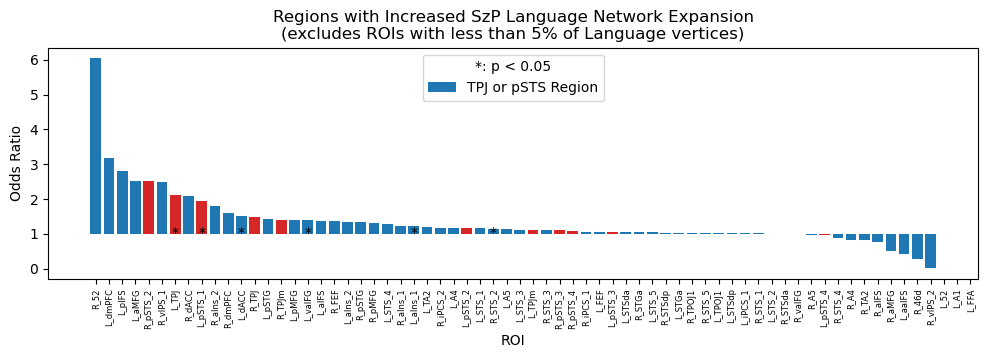

In [718]:
c = np.array(["C3" if any(tok in v.lower() for tok in ["tpj", "psts"])else "C0" for v in both_rois["node"]])

fig, ax = plt.subplots(figsize=(12, 3))
plt.bar(both_rois["node"], both_rois["ORs"] - 1, bottom=1, color=c)
plt.xticks(fontsize=6, color='black', rotation=90);
ax.legend(["TPJ or pSTS Region"], title="*: p < 0.05")
# ax.set_ylim(0.7, 3)
ax.set(xlabel="ROI", ylabel="Odds Ratio",
       title=f"Regions with Increased SzP {network_interest} Network Expansion"
       f"\n(excludes ROIs with less than 5% of {network_interest} vertices)")

for node in nodes[p_s < 0.05].values:
    v = np.isnan(both_rois.query(f"node == '{node}'")["ORs"]).values[0]
    if not v:
        ax.text(node, 0.9, "*", ha="center", label="p < 0.05")


In [ ]:
test_language_classification(szp_rois[], hc_c, n_szp, n_hc)test_language_classification(szp_c, hc_c, n_szp, n_hc)

In [166]:
topo_roi_values = {}
for lab in sorted(parc.rh_label_indices.keys()):
    if lab == "???":
        continue
    ind = parc.rh_label_indices[lab]
    
    topo_roi_values[lab] = np.mean(prob_diff_values["right"][ind])


# for lab in sorted(parc.lh_label_indices.keys()):
#     if lab == "???":
#         continue
#     ind = parc.lh_label_indices[lab]
#     topo_roi_values[lab] = np.nanmean(prob_diff_values["left"][ind])

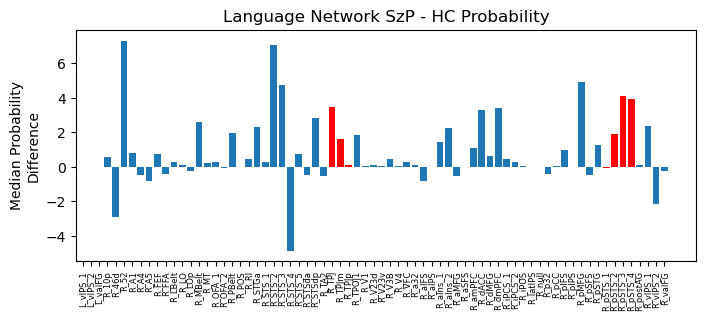

In [167]:
c = np.array(["r" if "tpj" in v.lower() or "psts" in v.lower() else "C0" for v in topo_roi_values.keys()])
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(topo_roi_values.keys(), topo_roi_values.values(), color=c)
ax.set(ylabel="Median Probability\nDifference", title=f"{network_interest} Network SzP - HC Probability")
plt.xticks(fontsize=6, color='black', rotation=90);

In [117]:
r_tpj_labels = parc.subset_labels(["R_TPJ", "L_TPJ"])

### PM Sizes differences
[] surface maps of expansion and contraction between szp vs hc
[] quantify stability: variable rs times, using HCP, etc

Text(0.5, 1.0, 'Default_Parietal Spatial Probability')

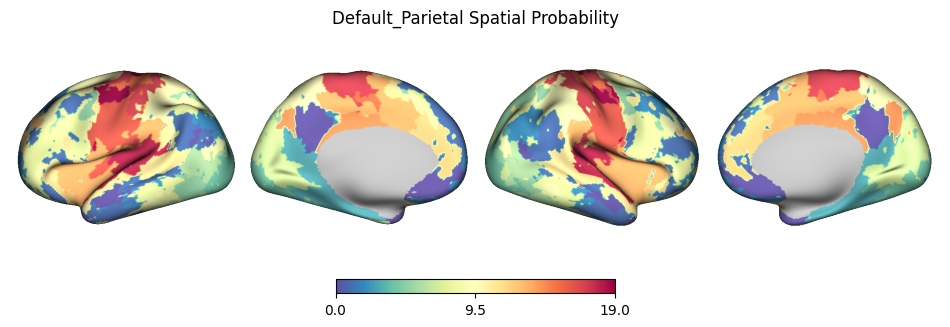

In [311]:
spatial_values_i = CAP_tools.utils.cifti_map(None, vertex_networks, example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(spatial_values_i, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"{network_labels[sp_index]} Spatial Probability")

Text(0.5, 1.0, 'Visual_Dorsal/VentralStream Spatial Probability')

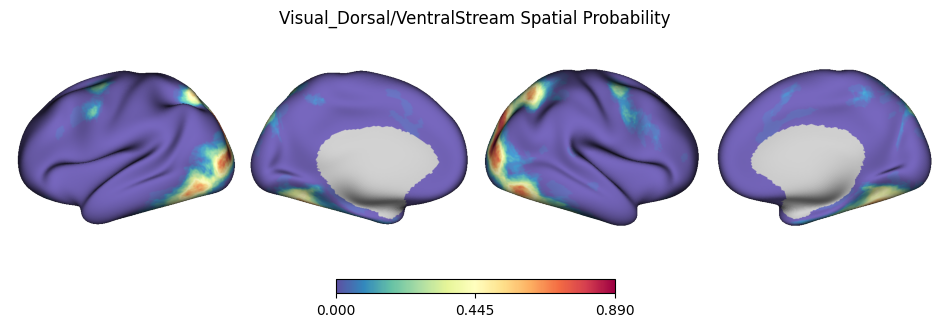

In [265]:
spatial_values_i = CAP_tools.utils.cifti_map(None, spatial[sp_index], example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(spatial_values_i, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"{network_labels[sp_index]} Spatial Probability")


# Load infomaps Parcellations

In [90]:
sparsity = 0.1
dist_threshold = 10
subcortex = True
prefix = "example"

In [91]:
example_cifti = nb.load(va.constants.EXAMPLE_DTSERIES)

In [92]:
outputs_path = "/data/data7/network_control/projects/voxel_analysis/tests/outputs/"

subcortex_tag = "_SC" if subcortex else ""
param_tag = f"S{sparsity * 10:.0f}_D{dist_threshold}{subcortex_tag}"
partition_path = os.path.join(outputs_path, f"{prefix}_parcellation_{param_tag}.npy")

In [95]:
def process_partition(partition, cifti, min_voxels=0, n_vertices=91_282, filter_subcortex=True):
    """ """
    index, groups = partition
    # if filter_subcortex:
    #     subcortex_index = index >= (32_492 * 2)
    #     index, groups = index[~subcortex_index], np.unique(groups[~subcortex_index], return_inverse=True)[1]

    groups = np.random.permutation(np.max(groups))[groups - 1]    
    unique_groups, counts = np.unique(groups, return_counts=True)
    count_filter = np.isin(groups, unique_groups[counts >= min_voxels])
    
    vertex_labels = np.full(n_vertices, fill_value=np.nan)
    vertex_labels[index] = groups
    # vertex_labels[index[count_filter]] = groups[count_filter]
    
    precision_map_values = CAP_tools.utils.cifti_map(None, vertex_labels, cifti)
    # precision_map_values = CAP_tools.utils.cifti_map(index, groups, cifti)
    return precision_map_values, (index, groups)

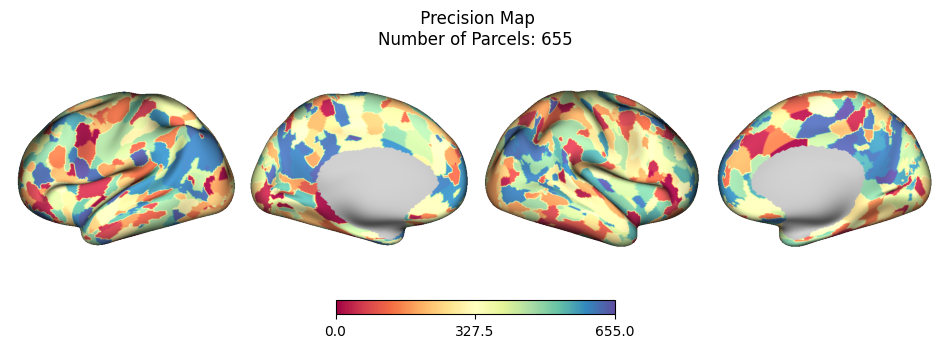

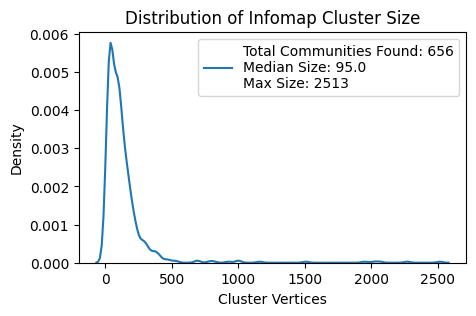

In [96]:
partition = np.load(partition_path)
precision_map_values, partition = process_partition(partition, example_cifti)

va.pm.plot_precision_map(precision_map_values)
va.pm.precision_map_QC_plots(partition)
# va.pm.write_dlabel_precision_map(precision_map_values, dlabel_path, label="example_precision_map")

# Distance and Subcortical Masking

In [69]:
sfm.get_cortex_mask(rs_dtseries)

array([ True,  True,  True, ..., False, False, False])

In [70]:
dist_dir = "/data/data7/network_control/projects/network_control/resources/brain_distances"
ex_dist_txt_path = os.path.join(dist_dir, "Schaefer400_geodesic_distmat_R.txt")
ex_dist_txt_path = os.path.join(dist_dir, "dense_geodesic_distmat_R.txt")

geodesic_distmat_L_path = os.path.join(dist_dir, "dense_geodesic_distmat_L.txt")
geodesic_distmat_R_path = os.path.join(dist_dir, "dense_geodesic_distmat_R.txt")

In [90]:
from scipy.sparse import lil_matrix

def create_sparse_matrix_from_txt(file_path, threshold=10.0, num_voxels=32_492):
    sparse_matrix = lil_matrix((num_voxels, num_voxels), dtype=np.float32)

    pbar = tqdm(total=num_voxels)
    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            distances = line.strip().split()
            for j, dist in enumerate(distances):
                dist_value = float(dist)
                if dist_value <= threshold and i != j:
                    sparse_matrix[i, j] = dist_value
            pbar.update(1)
    return sparse_matrix

In [91]:
threshold = 30
geodesic_dist_mask_R = create_sparse_matrix_from_txt(geodesic_distmat_R_path, threshold=threshold)
geodesic_dist_mask_L = create_sparse_matrix_from_txt(geodesic_distmat_L_path, threshold=threshold)

  0%|          | 0/32492 [00:00<?, ?it/s]

  0%|          | 0/32492 [00:00<?, ?it/s]

In [92]:
geodesic_mask = scipy.sparse.block_diag([geodesic_dist_mask_L, geodesic_dist_mask_R])
geodesic_mask.resize(91282, 91282)
geodesic_mask = geodesic_mask.tocsr()

geodesic_mask_path = os.path.join(dist_dir, f"geodesic_mask_{threshold}.npz")
scipy.sparse.save_npz(geodesic_mask_path, geodesic_mask)
geodesic_mask

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 111710086 stored elements and shape (91282, 91282)>

# Calculate Euclidian Mask

In [643]:
subcortex_index = ~sfm.get_cortex_mask(rs_dtseries)
subcortex_mask_path = os.path.join(dist_dir, "subcortex_mask.npy")
np.save(subcortex_mask_path, subcortex_index)

In [644]:
subcortex_index = np.load(subcortex_mask_path)
geodesic_mask = scipy.sparse.load_npz(geodesic_mask_path)

In [639]:
sc = tmt.matrix.SparseCorrelator.run(rs_voxels[:, :], sparsity_percent=0.1, mask=geodesic_mask,
                                     exclude_index=subcortex_index,
                                     block_size=4000)

SparseCorrelator Block Analysis:   0%|          | 0/8464.0 [00:00<?, ?it/s]

In [645]:
sc = tmt.matrix.Runner.run(rs_voxels[:, :], mask=geodesic_mask,
                                     exclude_index=subcortex_index,
                                     block_size=4000)

<Axes: ylabel='Density'>

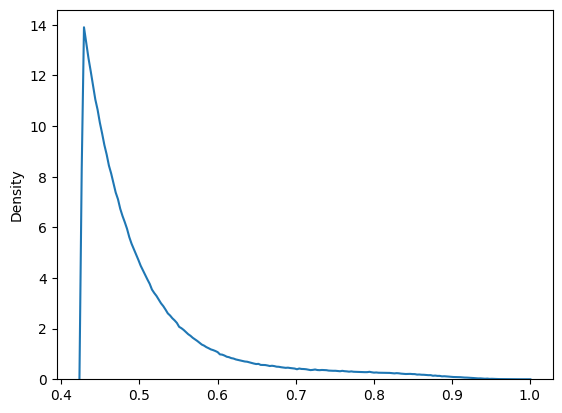

In [37]:
sns.kdeplot(sc.data, bw_method=0.01)

In [38]:
from sklearn.cluster import SpectralClustering
from scipy.sparse import csr_matrix

# Assuming 'sparse_matrix' is your scipy sparse matrix
# model = SpectralClustering(n_clusters=3, affinity='precomputed', n_init=100)
# labels = model.fit_predict(sc)

In [51]:
G = nx.from_scipy_sparse_matrix(sc)

AttributeError: module 'networkx' has no attribute 'from_scipy_sparse_matrix'

In [50]:
import networkx as nx
import community as community_louvain

partition = community_louvain.best_partition(G)

AttributeError: module 'networkx' has no attribute 'from_scipy_sparse_matrix'

In [41]:
(sc.sum(axis=1) == 0).sum()

np.int64(105)

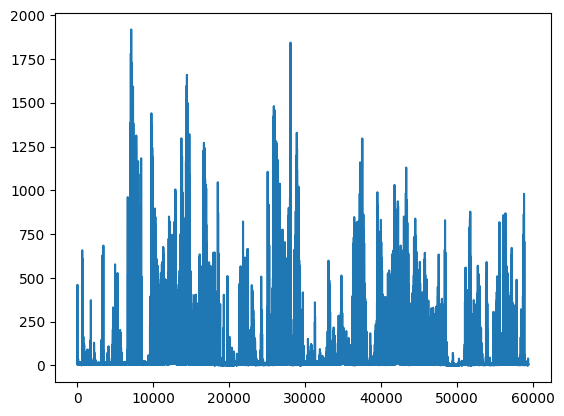

In [49]:
plt.plot(sc.getnnz(axis=0))

# Infomap

# EV Maxs

In [129]:
ev_maxs = tmt.matrix.block_analysis(voxel_data[:, :10000], tmt.matrix.ev_aggregator,
                                    device="mps", use_torch=True)

  0%|          | 0/10 [00:00<?, ?it/s]

In [56]:
(ev_maxs >= 0.5).mean() * 100

np.float64(86.18)

<Axes: ylabel='Density'>

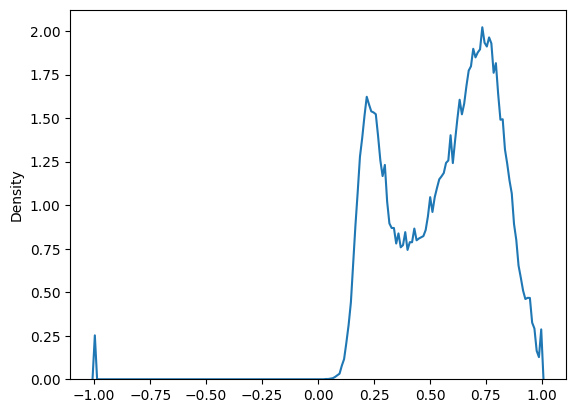

In [179]:
sns.kdeplot(ev_maxs, bw_method=0.01)

[] within parcel vs out of parcel correlations for voxel level

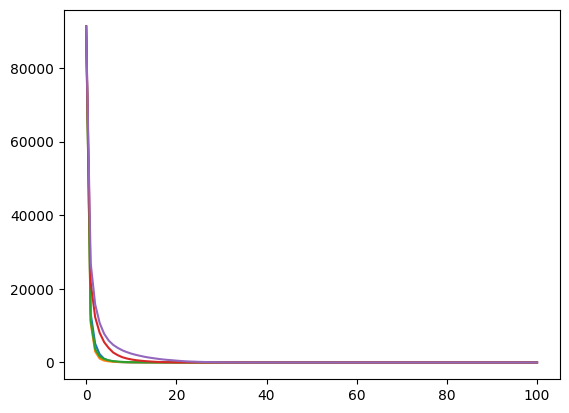

In [558]:
plt.plot(na_counts.T);

In [543]:
na_counts = {thres: [] for thres in np.linspace(0, 1, 101)}